# Porting walkthrough: Brunel, side by side

**What you'll learn / who it's for (porting / simulation).** A NEST network ported to `brainpy.state`, step for step. We take the Brunel (2000) random balanced network with **delta synapses** and show the NEST (PyNEST) construction next to the `brainpy.state` `Simulator` port — with a parameter-mapping table and the semantic divergences a port must account for.

The NEST code blocks below are shown for **reference only** (they need a live NEST install); the `brainpy.state` cells are runnable. Source: `examples/nest_like/brunel_delta.py` and NEST's `brunel_delta_nest.py`.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import brainstate
brainstate.environ.set(precision=64)

import numpy as np
import brainunit as u
import braintools
import matplotlib.pyplot as plt
from brainpy import state as bp

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Shared parameters

Both simulators use the identical Brunel knobs. With delta synapses the postsynaptic amplitude is a membrane-voltage jump, so `J_ex = J` directly — there is no current-to-voltage (`ComputePSPnorm`) rescaling that the alpha variant needs.

In [2]:
order = 100                          # small for a fast notebook run
g, eta, epsilon = 5.0, 2.0, 0.1
delay = 1.5                          # ms
NE, NI = 4 * order, 1 * order
CE, CI = int(epsilon * NE), int(epsilon * NI)
N_rec = 50
tauMem, CMem, theta, tref = 20.0, 1.0, 20.0, 2.0
J = 0.1                              # mV (delta jump)
J_ex = J
J_in = -g * J_ex
nu_th = theta / (J * CE * tauMem)
p_rate = 1000.0 * (eta * nu_th) * CE

## Step 1 — create populations and devices

**NEST (reference):**

```python
import nest
nest.SetKernelStatus({'resolution': 0.1})
nest.SetDefaults('iaf_psc_delta', {
    'C_m': CMem, 'tau_m': tauMem, 't_ref': tref,
    'E_L': 0.0, 'V_reset': 0.0, 'V_th': theta})
nodes_ex = nest.Create('iaf_psc_delta', NE)
nodes_in = nest.Create('iaf_psc_delta', NI)
noise = nest.Create('poisson_generator', params={'rate': p_rate})
espikes = nest.Create('spike_recorder')
ispikes = nest.Create('spike_recorder')
```

**brainpy.state (runnable):** there is no global kernel — a `Simulator` owns the populations, devices, and connections, and parameters carry explicit units.

In [3]:
npar = dict(C_m=CMem * u.pF, tau_m=tauMem * u.ms, t_ref=tref * u.ms,
            E_L=0. * u.mV, V_reset=0. * u.mV, V_th=theta * u.mV,
            V_initializer=braintools.init.Constant(0. * u.mV))

sim = bp.Simulator(dt=0.1 * u.ms)
ne = sim.create(bp.iaf_psc_delta, NE, params=npar)
ni = sim.create(bp.iaf_psc_delta, NI, params=npar)
noise = sim.create(bp.poisson_generator, rate=p_rate * u.Hz)
esr = sim.create(bp.spike_recorder)
isr = sim.create(bp.spike_recorder)

## Step 2 — connect

**NEST (reference):**

```python
nest.Connect(noise, nodes_ex + nodes_in,
             syn_spec={'weight': J_ex, 'delay': delay})
conn_ex = {'rule': 'fixed_indegree', 'indegree': CE}
conn_in = {'rule': 'fixed_indegree', 'indegree': CI}
nest.Connect(nodes_ex, nodes_ex + nodes_in, conn_ex,
             {'weight': J_ex, 'delay': delay})
nest.Connect(nodes_in, nodes_ex + nodes_in, conn_in,
             {'weight': J_in, 'delay': delay})
nest.Connect(nodes_ex[:N_rec], espikes)
nest.Connect(nodes_in[:N_rec], ispikes)
```

**brainpy.state (runnable):** `connect(src, dst, weight=, delay=, rule=)`, with `ne + ni` population algebra and `fixed_indegree(K)` — the same shape as `nest.Connect`. The delta weights are voltages in `mV`.

In [4]:
sim.connect(noise, ne, weight=J_ex * u.mV, delay=delay * u.ms, rule=bp.all_to_all)
sim.connect(noise, ni, weight=J_ex * u.mV, delay=delay * u.ms, rule=bp.all_to_all)
sim.connect(ne, ne + ni, weight=J_ex * u.mV, delay=delay * u.ms,
            rule=bp.fixed_indegree(CE), comm='sparse', allow_multapses=True, seed=1)
sim.connect(ni, ne + ni, weight=J_in * u.mV, delay=delay * u.ms,
            rule=bp.fixed_indegree(CI), comm='sparse', allow_multapses=True, seed=2)
sim.connect(ne[:N_rec], esr)
sim.connect(ni[:N_rec], isr)

## Step 3 — simulate and read back

**NEST (reference):** `nest.Simulate(1000.0)`, then `nest.GetStatus(espikes, 'n_events')` → rate.

**brainpy.state (runnable):** `sim.simulate(T)` returns a result; read the rate of a combined-population recorder via `esr.segments[0].population`.

excitatory rate: 60.56 spks/s
inhibitory rate: 60.18 spks/s


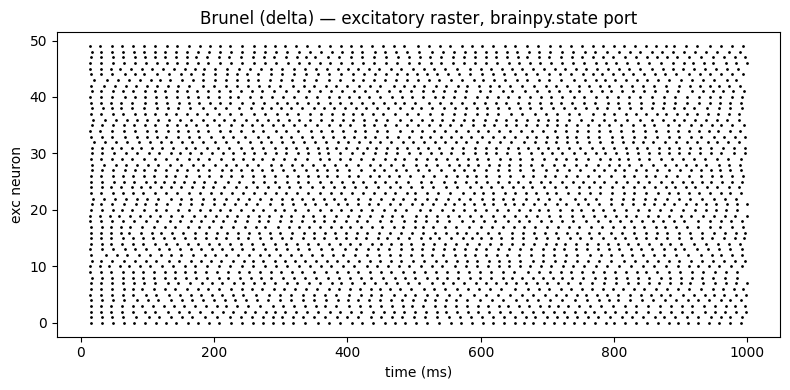

In [5]:
res = sim.simulate(1000. * u.ms)
erate = res.rate(esr.segments[0].population)
irate = res.rate(isr.segments[0].population)
print(f'excitatory rate: {erate:.2f} spks/s')
print(f'inhibitory rate: {irate:.2f} spks/s')

spk = np.asarray(res.spikes(esr.segments[0].population))
ts, ids = np.nonzero(spk > 0)
plt.figure(figsize=(8, 4))
plt.scatter(ts * 0.1, ids, s=1.0, color='k')
plt.xlabel('time (ms)'); plt.ylabel('exc neuron')
plt.title('Brunel (delta) — excitatory raster, brainpy.state port')
plt.tight_layout()

## Parameter mapping

| NEST | brainpy.state | Note |
|------|---------------|------|
| `nest.SetKernelStatus({'resolution': 0.1})` | `Simulator(dt=0.1 * u.ms)` | per-`Simulator`, no global kernel |
| `nest.Create('iaf_psc_delta', NE)` | `sim.create(bp.iaf_psc_delta, NE, params=...)` | returns a `NodeView` |
| `'C_m': 1.0` (pF implied) | `C_m=1.0 * u.pF` | units are explicit |
| `nodes_ex + nodes_in` | `ne + ni` | `NodeView` concatenation |
| `nodes_ex[:N_rec]` | `ne[:N_rec]` | `NodeView` slice |
| `{'rule': 'fixed_indegree', 'indegree': CE}` | `rule=bp.fixed_indegree(CE)` | same draw; `seed=` to reproduce |
| `syn_spec={'weight': J, 'delay': d}` | `weight=J * u.mV, delay=d * u.ms` | delta weight is a voltage (`mV`) |
| `nest.Simulate(T)` | `sim.simulate(T * u.ms)` | returns a `SimulationResult` |
| `nest.GetStatus(sr, 'n_events')` | `res.rate(...)` / `res.n_events(...)` | read from the result |

## Divergences this port runs into

- **Delta weights are voltages.** With `iaf_psc_delta` the postsynaptic amplitude is an instantaneous membrane-voltage jump, so weights are `mV` (`J_ex = J`), not the `pA` currents the alpha variant uses.
- **Independent PRNG streams.** The Poisson drive and the random `fixed_indegree` wiring draw from JAX's PRNG, which diverges sample-by-sample from NEST's. Parity for Brunel is therefore **distributional** — the seed-mean firing rate matches within a 5% band (category D), not spike-by-spike. See [validation status](validation-status.rst).
- **Sparse communication.** `comm='sparse'` selects the event-driven backend so large fan-in stays memory-light; `allow_multapses=True` matches NEST's `fixed_indegree` default (repeated edges sum).

For the full catalog — where learning state lives, parameter-location maps, the STDP pairing conventions, and the documented numerical bands — see the [semantic divergences](divergences/index.rst).

## See also

- [Connect a network](tutorials/03-connect-network.ipynb) — the same Brunel built from scratch.
- [Semantic divergences](divergences/index.rst) — the full porting catalog.
- [Validation status](validation-status.rst) — how Brunel parity is asserted (distributional, category D).
- [Example gallery](../examples/nest-gallery.rst) — full-scale Brunel and other ported networks.